# CIFAR-100 — ResNet18 Training Notebook
**Google Colab · GPU T4**

Exécute les cellules dans l'ordre. Tout est dans ce fichier.


## 0 · Vérification du GPU

In [ ]:
import torch
print("PyTorch :", torch.__version__)
print("GPU     :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "⚠️ Pas de GPU — active-le dans Runtime > Change runtime type > T4 GPU")
print("CUDA    :", torch.version.cuda)


PyTorch : 2.10.0+cu128
GPU     : Tesla T4
CUDA    : 12.8


## 1 · Installation des dépendances

In [ ]:
%%capture
!pip install torch torchvision scikit-learn matplotlib Pillow pyyaml


## 2 · Données CIFAR-100

**Option A — Téléchargement automatique (recommandé)**
Lance la cellule ci-dessous, elle télécharge et extrait CIFAR-100 automatiquement.

**Option B — Depuis Google Drive**
Si tu as déjà les fichiers sur Drive, commente l'option A et décommente l'option B.


In [ ]:
import os, tarfile, urllib.request

DATA_DIR = '/content/cifar100'
os.makedirs(DATA_DIR, exist_ok=True)

# ── Option A : téléchargement automatique ──────────────────────────────────
URL      = 'https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz'
ARCHIVE  = '/content/cifar100.tar.gz'

if not os.path.exists(os.path.join(DATA_DIR, 'train')):
    print("Téléchargement CIFAR-100...")
    urllib.request.urlretrieve(URL, ARCHIVE)
    print("Extraction...")
    with tarfile.open(ARCHIVE) as t:
        t.extractall('/content')
    # Les fichiers arrivent dans /content/cifar-100-python/
    import shutil
    for f in ['train', 'test', 'meta']:
        shutil.move(f'/content/cifar-100-python/{f}', DATA_DIR)
    print("✅ Données prêtes dans", DATA_DIR)
else:
    print("✅ Données déjà présentes")

TRAIN_PATH = os.path.join(DATA_DIR, 'train')
TEST_PATH  = os.path.join(DATA_DIR, 'test')

# ── Option B : depuis Google Drive ────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# TRAIN_PATH = '/content/drive/MyDrive/cifar100/train'
# TEST_PATH  = '/content/drive/MyDrive/cifar100/test'


Téléchargement CIFAR-100...
Extraction...


/tmp/ipykernel_1871/728235962.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('/content')


✅ Données prêtes dans /content/cifar100


## 3 · Hyperparamètres — modifie ici uniquement

In [ ]:
CFG = {
    'model'       : 'resnet18',   # 'resnet18' ou 'resnet34'
    'epochs'      : 100,
    'batch_size'  : 128,
    'lr'          : 0.1,
    'momentum'    : 0.9,
    'weight_decay': 5e-4,
    'label_smooth': 0.1,
    'val_split'   : 0.1,
    'num_workers' : 2,            # 2 suffit sur Colab
    'ckpt_dir'    : '/content/checkpoints',
    # Pour sauvegarder dans Drive (persiste après déconnexion) :
    # 'ckpt_dir'  : '/content/drive/MyDrive/cifar100/checkpoints',
}
print("Config :", CFG)


Config : {'model': 'resnet18', 'epochs': 100, 'batch_size': 128, 'lr': 0.1, 'momentum': 0.9, 'weight_decay': 0.0005, 'label_smooth': 0.1, 'val_split': 0.1, 'num_workers': 2, 'ckpt_dir': '/content/checkpoints'}


## 4 · Dataset & DataLoaders

In [ ]:
import pickle
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision.transforms as T

MEAN = (0.5071, 0.4867, 0.4408)
STD  = (0.2675, 0.2565, 0.2761)

class CIFAR100Dataset(Dataset):
    def __init__(self, path, transform=None):
        with open(path, 'rb') as f:
            d = pickle.load(f, encoding='bytes')
        self.images    = d[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        self.labels    = np.array(d[b'fine_labels'], dtype=np.int64)
        self.transform = transform

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        img = Image.fromarray(self.images[i])
        if self.transform: img = self.transform(img)
        return img, int(self.labels[i])

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.2, 0.2, 0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
val_tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

# Split train / val
full_tr = CIFAR100Dataset(TRAIN_PATH, train_tf)
full_vl = CIFAR100Dataset(TRAIN_PATH, val_tf)
n_val   = int(len(full_tr) * CFG['val_split'])
n_train = len(full_tr) - n_val
g = torch.Generator().manual_seed(42)
tr_idx, vl_idx = random_split(range(len(full_tr)), [n_train, n_val], generator=g)

train_loader = DataLoader(Subset(full_tr, tr_idx.indices), batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
val_loader   = DataLoader(Subset(full_vl, vl_idx.indices), batch_size=256,
                          shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(CIFAR100Dataset(TEST_PATH, val_tf), batch_size=256,
                          shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)

print(f"Train : {n_train:,}  |  Val : {n_val:,}  |  Test : {len(test_loader.dataset):,}")


Train : 45,000  |  Val : 5,000  |  Test : 10,000


## 5 · Modèle ResNet

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    expansion = 1
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=100):
        super().__init__()
        self.in_ch = 64
        self.conv1  = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        self.bn1    = nn.BatchNorm2d(64)
        self.layer1 = self._make(block, 64,  layers[0], 1)
        self.layer2 = self._make(block, 128, layers[1], 2)
        self.layer3 = self._make(block, 256, layers[2], 2)
        self.layer4 = self._make(block, 512, layers[3], 2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(512, num_classes)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
    def _make(self, block, ch, n, stride):
        layers = [block(self.in_ch, ch, stride)]
        self.in_ch = ch
        for _ in range(1, n): layers.append(block(ch, ch))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        return self.fc(torch.flatten(self.pool(x), 1))

def build_model(name='resnet18'):
    cfgs = {'resnet18': [2,2,2,2], 'resnet34': [3,4,6,3]}
    return ResNet(ResidualBlock, cfgs[name])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = build_model(CFG['model']).to(device)
total  = sum(p.numel() for p in model.parameters())
print(f"Modèle : {CFG['model']}  |  Paramètres : {total:,}  |  Device : {device}")


Modèle : resnet18  |  Paramètres : 11,220,132  |  Device : cuda


## 6 · Boucle d'entraînement

In [ ]:
import os, time
from torch.cuda.amp import GradScaler, autocast

criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smooth'])
optimizer = torch.optim.SGD(model.parameters(), lr=CFG['lr'],
                            momentum=CFG['momentum'], weight_decay=CFG['weight_decay'],
                            nesterov=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'], eta_min=1e-6)
scaler    = GradScaler()

os.makedirs(CFG['ckpt_dir'], exist_ok=True)

history   = {'tr_loss':[], 'vl_loss':[], 'tr_top1':[], 'vl_top1':[]}
best_top1 = 0.0

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    tot_loss = tot_c1 = tot_c5 = n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, lbs in loader:
            imgs, lbs = imgs.to(device), lbs.to(device)
            if train: optimizer.zero_grad(set_to_none=True)
            with autocast():
                out  = model(imgs)
                loss = criterion(out, lbs)
            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            bs       = imgs.size(0)
            tot_loss += loss.item() * bs
            _, p1    = out.max(1);           tot_c1 += p1.eq(lbs).sum().item()
            _, p5    = out.topk(5, 1);       tot_c5 += p5.eq(lbs[:,None]).any(1).sum().item()
            n += bs
    return tot_loss/n, 100*tot_c1/n, 100*tot_c5/n

print(f"{'Ep':>4} {'LR':>8} {'TrLoss':>8} {'TrTop1':>8} {'VlLoss':>8} {'VlTop1':>8} {'Time':>6}")
print("─"*60)

for ep in range(1, CFG['epochs']+1):
    t0 = time.time()
    tr_loss, tr1, tr5 = run_epoch(train_loader, train=True)
    vl_loss, vl1, vl5 = run_epoch(val_loader,   train=False)
    scheduler.step()
    elapsed = time.time()-t0
    lr_now  = optimizer.param_groups[0]['lr']

    history['tr_loss'].append(tr_loss); history['tr_top1'].append(tr1)
    history['vl_loss'].append(vl_loss); history['vl_top1'].append(vl1)

    print(f"{ep:4d} {lr_now:8.5f} {tr_loss:8.4f} {tr1:7.2f}% {vl_loss:8.4f} {vl1:7.2f}%  {elapsed:5.1f}s")

    if vl1 > best_top1:
        best_top1 = vl1
        torch.save({'epoch':ep,'model':model.state_dict(),
                    'optimizer':optimizer.state_dict(),
                    'best_top1':best_top1},
                   os.path.join(CFG['ckpt_dir'], 'best.pth'))
        print(f"  ✔ best.pth sauvegardé  (Top-1 val = {best_top1:.2f}%)")

print(f"\n✅ Entraînement terminé. Meilleur Top-1 val : {best_top1:.2f}%")


  Ep       LR   TrLoss   TrTop1   VlLoss   VlTop1   Time
────────────────────────────────────────────────────────────


/tmp/ipykernel_1871/4039528460.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_1871/4039528460.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   1  0.09998   3.9613   12.09%   3.5579   19.16%   35.3s
  ✔ best.pth sauvegardé  (Top-1 val = 19.16%)
   2  0.09990   3.3057   25.37%   3.1543   28.56%   31.4s
  ✔ best.pth sauvegardé  (Top-1 val = 28.56%)
   3  0.09978   2.8729   35.76%   2.9153   36.92%   32.1s
  ✔ best.pth sauvegardé  (Top-1 val = 36.92%)
   4  0.09961   2.5988   43.56%   2.5972   43.92%   31.4s
  ✔ best.pth sauvegardé  (Top-1 val = 43.92%)
   5  0.09938   2.4202   48.67%   2.5287   45.44%   33.3s
  ✔ best.pth sauvegardé  (Top-1 val = 45.44%)
   6  0.09911   2.2896   52.52%   2.5964   44.60%   31.0s
   7  0.09880   2.1860   55.76%   2.2968   52.48%   31.7s
  ✔ best.pth sauvegardé  (Top-1 val = 52.48%)
   8  0.09843   2.0981   58.37%   2.2593   53.38%   31.8s
  ✔ best.pth sauvegardé  (Top-1 val = 53.38%)
   9  0.09801   2.0386   60.33%   2.3339   51.36%   31.1s
  10  0.09755   1.9831   61.85%   2.1705   55.84%   32.4s
  ✔ best.pth sauvegardé  (Top-1 val = 55.84%)
  11  0.09704   1.9386   63.06%   2.2819   52.06%   

## 7 · Courbes d'entraînement

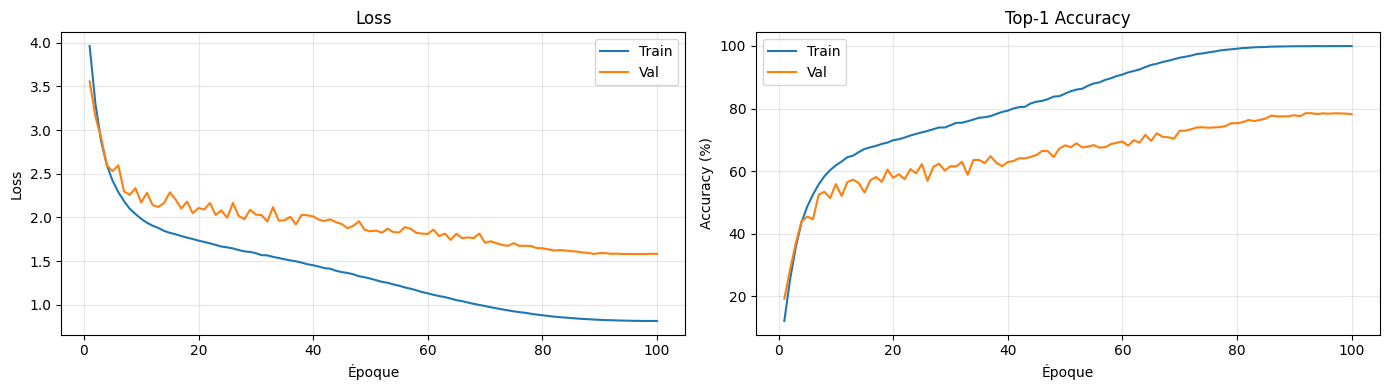

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
eps = range(1, len(history['tr_loss'])+1)

ax1.plot(eps, history['tr_loss'], label='Train')
ax1.plot(eps, history['vl_loss'], label='Val')
ax1.set(xlabel='Époque', ylabel='Loss', title='Loss'); ax1.legend(); ax1.grid(alpha=.3)

ax2.plot(eps, history['tr_top1'], label='Train')
ax2.plot(eps, history['vl_top1'], label='Val')
ax2.set(xlabel='Époque', ylabel='Accuracy (%)', title='Top-1 Accuracy'); ax2.legend(); ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()


## 8 · Évaluation finale sur le jeu de test

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

CLASSES = [
    'apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle','bicycle','bottle',
    'bowl','boy','bridge','bus','butterfly','camel','can','castle','caterpillar','cattle',
    'chair','chimpanzee','clock','cloud','cockroach','couch','crab','crocodile','cup',
    'dinosaur','dolphin','elephant','flatfish','forest','fox','girl','hamster','house',
    'kangaroo','keyboard','lamp','lawn_mower','leopard','lion','lizard','lobster','man',
    'maple_tree','motorcycle','mountain','mouse','mushroom','oak_tree','orange','orchid',
    'otter','palm_tree','pear','pickup_truck','pine_tree','plain','plate','poppy',
    'porcupine','possum','rabbit','raccoon','ray','road','rocket','rose','sea','seal',
    'shark','shrew','skunk','skyscraper','snail','snake','spider','squirrel','streetcar',
    'sunflower','sweet_pepper','table','tank','telephone','television','tiger','tractor',
    'train','trout','tulip','turtle','wardrobe','whale','willow_tree','wolf','woman','worm',
]

# Charger le meilleur checkpoint
ckpt = torch.load(os.path.join(CFG['ckpt_dir'], 'best.pth'), map_location=device)
model.load_state_dict(ckpt['model'])
print(f"Checkpoint époque {ckpt['epoch']} chargé (best val Top-1 = {ckpt['best_top1']:.2f}%)")

model.eval()
all_preds, all_labels = [], []
c1 = c5 = total = 0

with torch.no_grad():
    for imgs, lbs in test_loader:
        imgs, lbs = imgs.to(device), lbs.to(device)
        with autocast(): out = model(imgs)
        _, p1 = out.max(1);       c1 += p1.eq(lbs).sum().item()
        _, p5 = out.topk(5, 1);   c5 += p5.eq(lbs[:,None]).any(1).sum().item()
        total += lbs.size(0)
        all_preds.append(p1.cpu().numpy())
        all_labels.append(lbs.cpu().numpy())

preds  = np.concatenate(all_preds)
labels = np.concatenate(all_labels)
print(f"\n{'─'*40}")
print(f"  Top-1 accuracy : {100*c1/total:.2f}%")
print(f"  Top-5 accuracy : {100*c5/total:.2f}%")
print(f"{'─'*40}")

# Accuracy par classe — top 5 et bottom 5
accs = {CLASSES[i]: 100*(preds[labels==i]==i).sum()/(labels==i).sum() for i in range(100)}
sorted_accs = sorted(accs.items(), key=lambda x: x[1], reverse=True)
print("\nTop-5 classes :")
for n,a in sorted_accs[:5]: print(f"  {n:<22} {a:.1f}%")
print("\nBottom-5 classes :")
for n,a in sorted_accs[-5:]: print(f"  {n:<22} {a:.1f}%")


Checkpoint époque 92 chargé (best val Top-1 = 78.52%)


/tmp/ipykernel_1871/2701579248.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): out = model(imgs)



────────────────────────────────────────
  Top-1 accuracy : 77.79%
  Top-5 accuracy : 94.18%
────────────────────────────────────────

Top-5 classes :
  motorcycle             95.0%
  sunflower              95.0%
  mountain               94.0%
  road                   94.0%
  wardrobe               94.0%

Bottom-5 classes :
  bowl                   57.0%
  woman                  55.0%
  seal                   54.0%
  otter                  50.0%
  boy                    47.0%


## 9 · Matrice de confusion (top-20 classes)

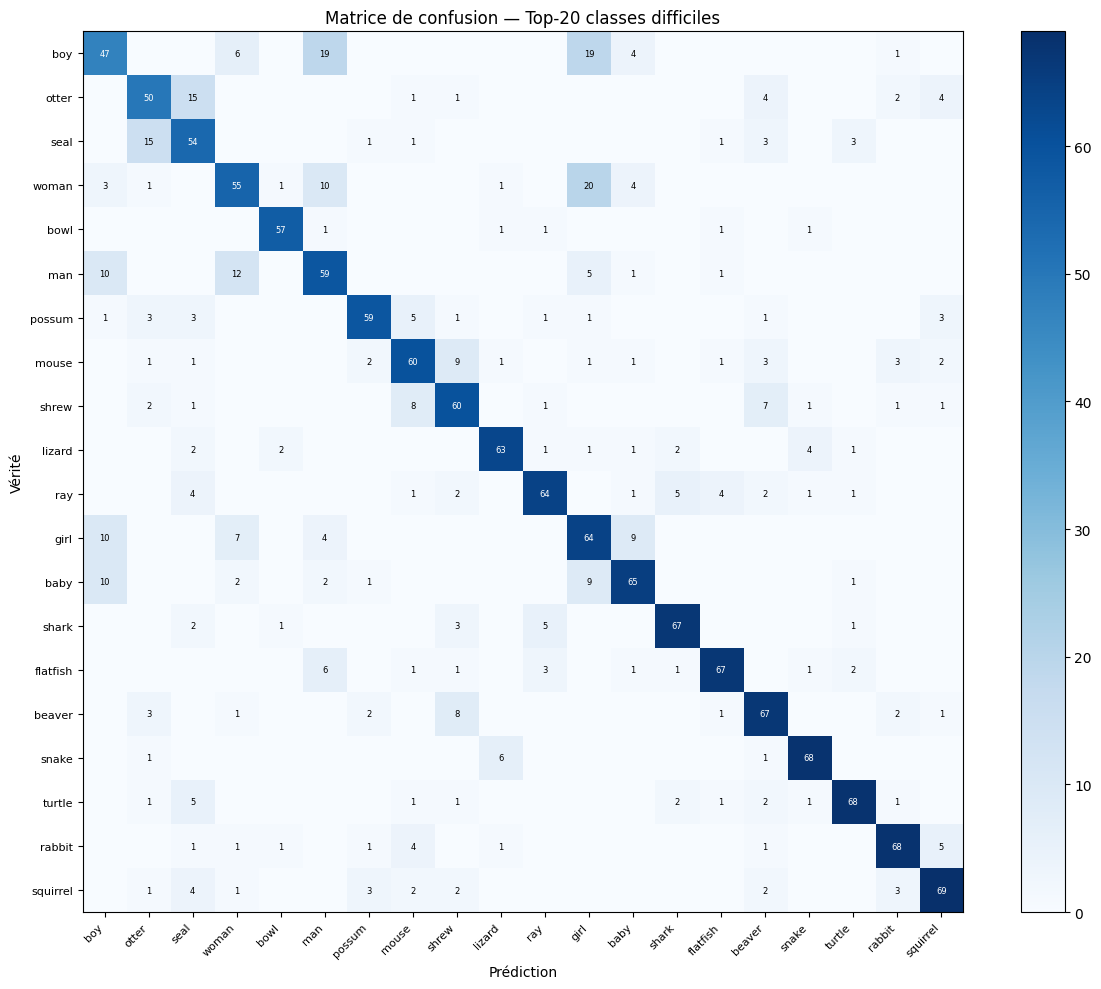

In [ ]:
from sklearn.metrics import confusion_matrix

errors     = labels[preds != labels]
top_cls    = np.argsort(np.bincount(errors, minlength=100))[::-1][:20]
mask       = np.isin(labels, top_cls)
cm         = confusion_matrix(labels[mask], preds[mask], labels=top_cls)
cls_names  = [CLASSES[i] for i in top_cls]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set(xticks=range(20), yticks=range(20),
       xticklabels=cls_names, yticklabels=cls_names,
       xlabel='Prédiction', ylabel='Vérité', title='Matrice de confusion — Top-20 classes difficiles')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)
thresh = cm.max()/2
for i in range(20):
    for j in range(20):
        if cm[i,j]:
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=6,
                    color='white' if cm[i,j]>thresh else 'black')
plt.tight_layout(); plt.show()


## 10 · (Optionnel) Sauvegarder le checkpoint dans Google Drive

In [ ]:
# Décommente et exécute si tu veux conserver le modèle après la session Colab

# from google.colab import drive
# drive.mount('/content/drive')
# import shutil, os
# dst = '/content/drive/MyDrive/cifar100/checkpoints'
# os.makedirs(dst, exist_ok=True)
# shutil.copy(os.path.join(CFG['ckpt_dir'], 'best.pth'), dst)
# print("✅ best.pth sauvegardé dans Drive →", dst)
